In [1]:
## SAVING FILES EXMAPLE

# aggregated_hourly = filtered_output_root_folder / "final_aggregated/services_hourly.parquet"
# con.execute(f"COPY services_hourly_agg TO '{aggregated_hourly}' (FORMAT PARQUET)")
# print("Done! Saved as ", aggregated_hourly)

DOWNLOAD:

- results/
- downloads/data/filtered/final_aggregated/monthly_rows_with_missing_values.csv
- downloads/data/filtered/final_aggregated/final_model_training_data_2019.parquet

# Prior work insights:

Lei's:
- Goal: Predict edge based on Topological features only (excluding any geographical i.e. spatial and temporal information)
- Prediction Task: Monthly edge removal prediction (supervised binary classification defined as link prediction)
- Class imbalance strategy: random undersampling
- Dynamic network
- Brute force grid search 
- Models: XGBoost best (27 models evaluated)
- Lei's trained on non simultaneous (same time), to predict on same time, simultaneous trained on network on specific time (partially) to predict the remaining part. 
- Conclusion: Showed it's possible to do edge classification (link prediction) based on (local) topological features for fast changing networks
- Future work: suggests adding to their limited feature set in various ways
- My critique/takeaway: Monthly timeline

Merel's: 
- Goal: Attempted generalizability of Lei's work to edge classification and slower changing network 
- Prediction Task: Monthly binary edge classification of 'significantly' DELAYED trajectory (supervised binary classification as edge classification)
- Class imbalance strategy: Reclassification ground truth label per trajectory (aggregated trajectory) based on entire data distribution
- Excluded weights due to leakage; compensated by adding node measurements to capture station importance instead
- Static network -> assumed due to slow changing nature 
- RandomSearchCV 
- Models: LR,RF,DT,GB,AdaBoost,XGBoost
- Conclusion: Topology features showed limited performance
- Future work: suggested to include temporal, operational and environmental data, data limitation of monthly aggregation, ensemble models
- My critique/takeaway: Monthly timeline, data (station) aggregation strategy, class imbalance strategy unsuitable, static network representation, weights were most important feature in Lei's work

Brent's:
- Goal: integrate spatial temporal features into dynamic graph based models + temporal component on daily time scale trajectory DISRUPTIONS
- Prediction Task: Daily binary edge classification of CANCELLED trajectories 
- Class imbalance strategy: tree based models scale_pos_weight, DGNN = class weighted entropy loss, SMOTE rejected due to unsuitability
- Dynamic network 
- RandomSearchCV
- Models: LR, RF, GB, XGB, DGNN (proposed)
- Conclusion: Complexity of DGNN limited performance increase, bad absolute performance, weather features not relevant, feature selection issues (LSTM permutation importance)
- Future Work: Higher resolution meteorology data, feature selection methods for sequence and graph models (to increase XAI), full scale tests with external data
- My critique/takeaways: Weather dataset quality issues, limited performance increase vs huge complexity (computation and interpretability tradeoff), XGBoost similar so back to 

Ours: 
- Goal: Reevaluate Lei's generalizability of topological features for edge classification and evaluate operational (lag and preplanned schedule information) features, environmental features for tree based models.
- Prediction task: Hourly binary edge classification of DELAYED trajectories (i.e. predicting network state; will a trajectory be delayed or not (binary), for short term delay management)
- Class imbalance strategy: classification label definition (>0min passenger experience perpective), and tree based models scale_pos_weight
- Dynamic network, due to hourly granularity
- Hyperparameter: RandomSearchCV full dataset
- Models: LR, XGB, HistBoost (LGBM)
- Conclusion: TBD, limitations
- Future work: TBD, limitations
- Motivation for work to tackle LIMITATIONS of prior work I propose: Hourly (Merel data limitation), Stop level trajectory aggregation (Merel data limitation), Redefined classification label (Merel imbalance strategy), back to tree based models (Brent's increased complexity but limited performance increase compared to XGB in most settings), higher resolution of meteorology data (Brent's weather data limitation)


# Classification models notebook

## Imports

In [2]:
# ============================================================================
# SECTION 1: IMPORTS
# ============================================================================
# Import all necessary libraries for model training, evaluation, and visualization

import os
import random
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, make_scorer, f1_score, precision_score, recall_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
import torch
import matplotlib.pyplot as plt

import duckdb
######################

import sys
import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as ss

from tqdm import tqdm
# from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix,balanced_accuracy_score, mean_squared_error,r2_score,mean_absolute_error

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import os
import joblib 
from tqdm import tqdm

# --- Models ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import learning_curve
from lightgbm import LGBMClassifier

# --- Preprocessing & Tuning ---
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline 
from sklearn.metrics import f1_score, roc_auc_score, balanced_accuracy_score

import shap
from sklearn.impute import SimpleImputer 

import gc

import warnings
from sklearn.exceptions import ConvergenceWarning, FitFailedWarning

# 1. Silence Scikit-Learn and Python warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FitFailedWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# 2. Silence LightGBM's specific C++ backend warnings
import os
os.environ['LGBM_WARNING'] = '0'

# 3. Configure your Python logger to only show critical issues, not standard info/warnings
import logging
logging.getLogger("lightgbm").setLevel(logging.ERROR)
logging.getLogger("xgboost").setLevel(logging.ERROR)

In [3]:
import sys
import random
import datetime
import shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as ss

from datetime import date
from tqdm import tqdm
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, balanced_accuracy_score, mean_squared_error, r2_score, mean_absolute_error

In [4]:
import sys
import random
import logging
import numpy as np
import pandas as pd
from tqdm import tqdm
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import RidgeClassifier, LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score


## Globals

In [5]:
# GLOBALS
# Set true for snellius job
snellius = True # Set True for snellius, False for local development
shap_analysis = False 

run_baseline = False
run_new = True
balanced_class_weights = False # Utilize classweights

# LOCAL TESTING, SET FALSE
shap_sample = False # testing, but doesnt seem to be the bottle neck with baseline 
subset_dataset = False # set true for quick local subset testing

TRAINING_FROM_YEAR = 2019
search_param = False

# Misc
partition = "services_full" if snellius else "services_subset"
PARAMETERS_FILENAME = "HPARAM" if search_param else "DEFAULT"
FILENAME_PARTITION = "SUBSET" if subset_dataset else "FULL"
# FILENAME_PARTITION = "test" if subset_dataset else "test_subset"
FILENAME_INFO = f"{PARAMETERS_FILENAME}_{FILENAME_PARTITION}_{TRAINING_FROM_YEAR}"

xgb_device = 'cuda' if torch.cuda.is_available() else 'cpu'

RANDOM_SEED = 88 # For reproducibility
run_analysis = False #old hourly remove/adjust later

In [ ]:
# KEY POINT: These are NOT time series sequences. Instead:
# - Each row represents ONE TRAJECTORY on ONE HOUR ON A SPECIFIC DATE
import os
from pathlib import Path

if snellius is False:
    # Change later to snellius $HOME or whatever folder you want to work in
    target_root = Path(r"C:\Users\jialo\Desktop\MSc-DS-Thesis\MSc-Thesis-Repo\MSc-Thesis\Bao")

    # Check if it exists before moving
    if target_root.exists():
        os.chdir(target_root)
        print(f"✅ Success! Moved to: {Path.cwd()}")
    else:
        print(f"❌ Error: The folder '{target_root}' does not exist.")

In [ ]:
if snellius is True:
    # Get the home directory path object
    home_dir = Path.home() 

    # Build a path to your code
    target_root = home_dir / "NS_Thesis"

    print(target_root)

/home/jbao/NS_Thesis


## File paths

In [ ]:
project_root = target_root
final_data_root = project_root / "downloads/data/filtered/final_aggregated"
final_data_filepath = final_data_root / "final_dataset_with_operational.parquet"

media_folder = project_root / "media"
models_folder = project_root / "models"
results_folder = project_root / "results"

results_xgb = results_folder / "results_XGB"

results_classifiers = results_folder / "result_classifiers"

if not search_param:
    # 1. Dynamically set the folder name based on the boolean
    folder_name = "results_classifiers_DEF" if balanced_class_weights else "results_classifiers_DEF_NCW"
    
    # 2. Create the full path object
    results_classifiers = results_folder / folder_name
    
    # 3. Create the directory safely (does nothing if it already exists)
    results_classifiers.mkdir(parents=True, exist_ok=True)
    
    print(f"Saving baseline models to: {results_classifiers.name}")

Saving baseline models to: results_classifiers_DEF_NCW


## Connect duckDB database

In [ ]:
## Connect to database
db_name = f"{FILENAME_INFO}_main_classifications.duckdb"

# Check before
print(f"Does file exist? {os.path.exists(db_name)}")

con = duckdb.connect(database=db_name)

# Optional: Explicitly cap RAM so DuckDB knows WHEN to start spilling
# (e.g., set to 70-80% of your actual machine RAM)
if snellius is False:
    con.execute("SET memory_limit='5GB'")   

Does file exist? True


In [ ]:
con.execute(f"""
    CREATE OR REPLACE VIEW services_final AS 
    FROM read_parquet('{final_data_filepath}')""") 

## Feature lists

### FILTERED
src.degree              AS src_degree, # rides planned (to arrive)
src.weighted_degree     AS src_weighted_degree, # Total rides planned (inbound and outbound), brent only inbound
src.avg_distance        AS src_avg_distance, # Weighted average distance of rides planned in and outbound neighbours, brent only inbound

In [11]:
# # Weight feature
# topology_weight_feature = [
# 	'decayed_edge_weight'
# ]

# #consistent with prior
# topology_features = [
# 	'src_degree', 'src_w_deg_inbound',
# 	'src_avg_distance_in', 
# 	'common_neighbors', 'jaccard_coefficient', 'preferential_attachment',
# 	'adamic_adar_index', 'resource_allocation_index',
# ]

# weather_features = [
# 	'src_avg_temperature_2m', 'src_avg_rain', 'src_avg_snowfall',
# 	'src_avg_snow_depth', 'src_avg_wind_speed_10m',
# 	'src_avg_wind_gusts_10m', 'src_avg_soil_temperature',
# ]

# cyclical_features = [
# 	'season_ordinal', 'month_sin', 'month_cos'
# ]

# calendar_features = cyclical_features + ['total_holidays',
# 'holiday_density_ratio', 'weekend_days', 'working_days',
# ]

# # operational feature engineering, define in paper
# operational_features = [
# 	'distance',
# 	'last_active_volume', 
# 	'months_since_last_service', 
# 	# 'decayed_edge_weight',
# 	'is_new_or_stale_route',
# ]

# # From historical service, not engineered
# service_features = [
# 	'source', 'target', 'distance', 'year', 'month'
# ]

# non_numeric_features = [
# 	'source', 'target', 'YearMonth', 'last_active_month',
# ]

# all_num_features = topology_features + topology_weight_feature + weather_features + calendar_features + operational_features

# # all_features = service_features + topology_features + topology_weight_feature + weather_features + calendar_features + operational_features

# # multiclass dropped for now
# target_features = ['target_binary']

# # features unknown at prediction time and utilized to calculate operational lag features and redundant 
# features_to_drop = [
# 	'total_departure_delay_minutes', 'avg_departure_delay_minutes',
# 	'count_delayed_departure_services', 'total_delay_minutes',
# 	'avg_delay_minutes', 'count_delayed_services', 'total_services',
# 	'ratio_departure_delayed', 'ratio_arrival_delayed',
# 	'count_platform_changes', 'train_type_counts',
# 	'global_median', 'target_binary', 'raw_intercity',
# 	'raw_intercity_direct', 'raw_international', 'raw_exceptions',
# 	# topology redundant
# 	'src_avg_distance_out',
# 	'src_w_deg_outbound', 'src_w_deg_total', 'src_avg_distance_total',
# 	'tgt_avg_distance_in', 'tgt_avg_distance_out',
# 	'tgt_w_deg_inbound', 'tgt_w_deg_outbound', 'tgt_w_deg_total',
# 	'tgt_degree',
# 	'tgt_avg_distance_total', 
# 	# weather redundant
# 	'tgt_avg_temperature_2m', 'tgt_avg_rain', 'tgt_avg_snowfall',
# 	'tgt_avg_snow_depth', 'tgt_avg_wind_speed_10m',
# 	'tgt_avg_wind_gusts_10m', 'tgt_avg_soil_temperature',
# 	# cal redundant
# 	'month',
# 	# operational redundant
# 	'ratio_intercity', 'ratio_intercity_direct', 'ratio_international',
# 	'ratio_operational_exceptions', 'ratio_sprinter',
# ]

# initial_cols_to_drop = ['train_type_counts', 'last_active_month']

# Full feature set

In [ ]:
# Weight features
topology_weight_feature = [
    'decayed_edge_weight', 
    'src_w_deg_inbound', 'src_w_deg_outbound', 'src_w_deg_total',
    'tgt_w_deg_inbound', 'tgt_w_deg_outbound', 'tgt_w_deg_total',
]

#consistent with prior
topology_features = [
    'src_degree', # number of connections
    'tgt_degree', # number of connections
    'src_avg_distance_in', 
    'common_neighbors', 'jaccard_coefficient', 'preferential_attachment',
    'adamic_adar_index', 'resource_allocation_index',
    'src_avg_distance_out', 'src_avg_distance_total',
    'tgt_avg_distance_in', 'tgt_avg_distance_out',
    'tgt_avg_distance_total',
]

weather_features = [
    'src_avg_temperature_2m', 'src_avg_rain', 'src_avg_snowfall',
    'src_avg_snow_depth', 'src_avg_wind_speed_10m',
    'src_avg_wind_gusts_10m', 'src_avg_soil_temperature',
    'tgt_avg_temperature_2m', 'tgt_avg_rain', 'tgt_avg_snowfall',
    'tgt_avg_snow_depth', 'tgt_avg_wind_speed_10m',
    'tgt_avg_wind_gusts_10m', 'tgt_avg_soil_temperature',
]

cyclical_features = [
    # 'season_ordinal', 'month_sin', 'month_cos'
]

calendar_features = cyclical_features + [
#     'total_holidays',
# 'holiday_density_ratio', 'weekend_days', 'working_days',
# 'month',
]

# operational feature engineering, define in paper
operational_features = [
    'distance',
    'last_active_volume', 
    'months_since_last_service', 
    # 'decayed_edge_weight', 
    'is_new_or_stale_route',
    'ratio_intercity', 'ratio_intercity_direct', 'ratio_international',
    'ratio_operational_exceptions', 'ratio_sprinter',
]

# From historical service, not engineered
service_features = [
    'source', 'target', 'distance', 'year', 'month'
]

non_numeric_features = [
    'source', 'target', 'YearMonth', 'last_active_month',
]

all_num_features = topology_features + topology_weight_feature + weather_features + calendar_features + operational_features

# all_features = service_features + topology_features + topology_weight_feature + weather_features + calendar_features + operational_features

# multiclass dropped for now
target_features = ['target_binary']

# features unknown at prediction time and utilized to calculate operational lag features and redundant 
features_to_drop = [
    'total_departure_delay_minutes', 'avg_departure_delay_minutes',
    'count_delayed_departure_services', 'total_delay_minutes',
    'avg_delay_minutes', 'count_delayed_services', 'total_services',
    'ratio_departure_delayed', 'ratio_arrival_delayed',
    'count_platform_changes', 'train_type_counts',
    'global_median', 'target_binary', 'raw_intercity',
    'raw_intercity_direct', 'raw_international', 'raw_exceptions',
    # topology redundant
    # 'src_avg_distance_out',
    # 'src_w_deg_outbound', 'src_w_deg_total', 'src_avg_distance_total',
    # 'tgt_avg_distance_in', 'tgt_avg_distance_out',
    # 'tgt_w_deg_inbound', 'tgt_w_deg_outbound', 'tgt_w_deg_total',
    # 'tgt_degree',
    # 'tgt_avg_distance_total', 
    # weather redundant
    # 'tgt_avg_temperature_2m', 'tgt_avg_rain', 'tgt_avg_snowfall',
    # 'tgt_avg_snow_depth', 'tgt_avg_wind_speed_10m',
    # 'tgt_avg_wind_gusts_10m', 'tgt_avg_soil_temperature',
    # cal redundant
    # 'month',
    # operational redundant
    # 'ratio_intercity', 'ratio_intercity_direct', 'ratio_international',
    # 'ratio_operational_exceptions', 'ratio_sprinter',
]

initial_cols_to_drop = ['train_type_counts', 'last_active_month']

In [13]:
dataset_df = pd.read_parquet(final_data_filepath).drop(columns=initial_cols_to_drop)
dataset_df.columns

Index(['source', 'target', 'YearMonth', 'year', 'month', 'distance',
       'total_departure_delay_minutes', 'avg_departure_delay_minutes',
       'count_delayed_departure_services', 'total_delay_minutes',
       'avg_delay_minutes', 'count_delayed_services', 'total_services',
       'monthly_true_total_services', 'monthly_pure_delay_count',
       'monthly_cancellation_count', 'ratio_departure_delayed',
       'ratio_arrival_delayed', 'count_platform_changes', 'last_active_volume',
       'months_since_last_service', 'decayed_edge_weight',
       'is_new_or_stale_route', 'src_degree', 'src_w_deg_inbound',
       'src_w_deg_outbound', 'src_w_deg_total', 'src_avg_distance_total',
       'src_avg_distance_in', 'src_avg_distance_out', 'tgt_degree',
       'tgt_avg_distance_total', 'tgt_avg_distance_in', 'tgt_avg_distance_out',
       'tgt_w_deg_inbound', 'tgt_w_deg_outbound', 'tgt_w_deg_total',
       'common_neighbors', 'jaccard_coefficient', 'preferential_attachment',
       'adamic_ada

In [14]:
dataset_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49793 entries, 0 to 49792
Data columns (total 77 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   source                            49793 non-null  str    
 1   target                            49793 non-null  str    
 2   YearMonth                         49793 non-null  str    
 3   year                              49793 non-null  int64  
 4   month                             49793 non-null  int64  
 5   distance                          49793 non-null  int32  
 6   total_departure_delay_minutes     49793 non-null  float64
 7   avg_departure_delay_minutes       49793 non-null  float64
 8   count_delayed_departure_services  49793 non-null  int64  
 9   total_delay_minutes               49793 non-null  float64
 10  avg_delay_minutes                 49793 non-null  float64
 11  count_delayed_services            49793 non-null  int64  
 12  total_services 

In [15]:
con.execute("DROP VIEW IF EXISTS services_final")

In [16]:
# Convert your list into a comma-separated string for the SQL query
refined_drop_list = list(set(features_to_drop) - {'YearMonth'})
cols_to_exclude = ", ".join(refined_drop_list)

In [ ]:
con.execute(f"""
    CREATE OR REPLACE VIEW services_final AS 
    SELECT * EXCLUDE ({cols_to_exclude})
    FROM read_parquet('{final_data_filepath}') 
    ORDER BY year ASC, month ASC
""")

In [18]:
con.execute("""DESCRIBE services_final""").df()

,column_name,column_type,null,key,default,extra
0,source,VARCHAR,YES,None,None,None
1,target,VARCHAR,YES,None,None,None
2,YearMonth,VARCHAR,YES,None,None,None
3,year,BIGINT,YES,None,None,None
4,month,BIGINT,YES,None,None,None
...,...,...,...,...,...,...
57,ratio_operational_exceptions,FLOAT,YES,None,None,None
58,ratio_sprinter,FLOAT,YES,None,None,None
59,season_ordinal,INTEGER,YES,None,None,None
60,month_sin,DOUBLE,YES,None,None,None


# Filtering correlated features -> can and should we use shap instead (i.e. to highlight nonlinear relations for tree based models)

Spearman 0.85 threshold as per https://journals.lww.com/anesthesia-analgesia/fulltext/2018/05000/correlation_coefficients__appropriate_use_and.50.aspx

Amongst feature set 

Against target feature 

Graph the data

In [ ]:
# # Convert your list into a comma-separated string for the SQL query
# refined_drop_list = list(set(features_to_drop) - {'YearMonth', 'target_binary'})

# cols_to_exclude = ", ".join(refined_drop_list)

# con.execute(f"""
# 	CREATE OR REPLACE VIEW services_final AS 
# 	SELECT * EXCLUDE ({cols_to_exclude})
# 	FROM read_parquet('{final_data_filepath}') 
# 	ORDER BY year ASC, month ASC
# """)

# def get_uncorrelated_features(duckdb_con, table_name, feature_list, target_col='target_binary', threshold=0.85):
# 	# If the feature list is empty or has only 1 feature, return it immediately to avoid errors
# 	if len(feature_list) <= 1:
# 		return feature_list

# 	print(f"--- Running Target-Aware Spearman Correlation Filter (Threshold: {threshold}) ---")
    
# 	# 1. Pull the features AND the target column from DuckDB
# 	query = f"""
# 		SELECT {', '.join(feature_list)}, {target_col}
# 		FROM {table_name}
# 		-- WHERE month = 1 
# 	"""
# 	df_sample = duckdb_con.execute(query).df()
    
# 	# 2. Calculate Feature-to-Feature correlation (Spearman)
# 	feature_corr = df_sample[feature_list].corr(method='spearman').abs()
    
# 	# 3. Calculate Feature-to-Target correlation (Spearman)
# 	# We use absolute value because strong negative correlation is just as predictive as positive
# 	target_corr = df_sample[feature_list + [target_col]].corr(method='spearman')[target_col].abs()
    
# 	# 4. Extract the upper triangle of the matrix to avoid checking pairs twice
# 	upper_tri = feature_corr.where(np.triu(np.ones(feature_corr.shape), k=1).astype(bool))
    
# 	features_to_drop = set()
    
# 	print("Evaluating correlated pairs:")
# 	# 5. Iterate through the matrix to find features exceeding the threshold
# 	for col in upper_tri.columns:
# 		for row in upper_tri.index:
# 			if upper_tri.loc[row, col] > threshold:
                
# 				# Skip if we already decided to drop one of these features in a previous loop
# 				if row in features_to_drop or col in features_to_drop:
# 					continue
                
# 				# 6. THE TIE-BREAKER: Compare target correlations
# 				if target_corr[row] > target_corr[col]:
# 					features_to_drop.add(col) # col is weaker, drop it
# 					print(f"  - Dropped: '{col}' (Target Corr: {target_corr[col]:.3f}) | Kept: '{row}' (Target Corr: {target_corr[row]:.3f}) | Pair Corr: {upper_tri.loc[row, col]:.2f}")
# 				else:
# 					features_to_drop.add(row) # row is weaker, drop it
# 					print(f"  - Dropped: '{row}' (Target Corr: {target_corr[row]:.3f}) | Kept: '{col}' (Target Corr: {target_corr[col]:.3f}) | Pair Corr: {upper_tri.loc[row, col]:.2f}")
                    
# 	# 7. Create the clean feature list
# 	clean_features = [feat for feat in feature_list if feat not in features_to_drop]
    
# 	print(f"\nOriginal feature count: {len(feature_list)}")
# 	print(f"Features dropped:       {len(features_to_drop)}")
# 	print(f"Clean feature count:    {len(clean_features)}\n")
    
# 	return clean_features
# # clean_topology = get_uncorrelated_features(con, 'services_final', topology_features)
# # all_num_features = topology_features + topology_weight_feature + weather_features + calendar_features + operational_features

# weather_features = get_uncorrelated_features(con, 'services_final', weather_features)
# calendar_features = get_uncorrelated_features(con, 'services_final', calendar_features)
# operational_features = get_uncorrelated_features(con, 'services_final', operational_features)
# cw = get_uncorrelated_features(con, 'services_final', ['decayed_edge_weight'])

## Stations

Inclusion of ALL trains with NS label as company (Intercity, Sprinter etc.) + filtering down to NL stations resulted in 307 stations in the final services dataset

In [ ]:
if run_analysis:
    # Query to get the total count of unique stations
    unique_stations_count = con.execute("""
        SELECT count(DISTINCT station) 
        FROM (
            SELECT source AS station FROM services_final
            UNION 
            SELECT target AS station FROM services_final
        )
    """).fetchone()[0]

    print(f"Total unique stations: {unique_stations_count}")

# Dataset utilized

## Remaining NA values in pandas

last_active_month = NA represent the edges in the first month in our dataset -> should have 0 NA values now

In [ ]:
# --- NEW: Calculate and print missing % per column ---
total_rows = len(dataset_df)
missing_per_column = dataset_df.isna().sum()

# Filter to only show columns that actually have missing values
missing_columns_only = missing_per_column[missing_per_column > 0]

if not missing_columns_only.empty:
    print("\n[!] Breakdown of missing values per column:")
    
    # Loop through and print the count and percentage for each column
    for col, count in missing_columns_only.items():
        pct = (count / total_rows) * 100
        print(f"    - {col}: {count} missing ({pct:.2f}%)")
else:
    print("\n[OK] No missing values found in any columns.")

# 1. Identify rows with ANY missing values
rows_with_missing = dataset_df[dataset_df.isna().any(axis=1)]

if not rows_with_missing.empty:
    missing_count = len(rows_with_missing)
    missing_percentage = (missing_count / total_rows) * 100
    
    # --- SAVE TO PARQUET ---
    missing_filename = f"monthly_rows_with_missing_values.csv"
    missing_filename_path = final_data_root / missing_filename
    
    rows_with_missing.to_csv(missing_filename_path)
    
    print(f"\n[!] Dropping {missing_count} rows containing missing data ({missing_percentage:.2f}% of total).")
    print(f"    Saved these rows to: {missing_filename_path}")

# --- DROP FROM MAIN DATAFRAME ---
dataset_cleaned_df = dataset_df.dropna()


[OK] No missing values found in any columns.


# Final dataset for training

In [22]:
final_dataset_for_training_name = f"final_model_training_data_{TRAINING_FROM_YEAR}.parquet"
final_dataset_for_training_path = final_data_root / final_dataset_for_training_name
dataset_cleaned_df.to_parquet(final_dataset_for_training_path)
print(f"    Remaining rows: {len(dataset_cleaned_df)}")

    Remaining rows: 49793


Doublecheck

In [ ]:
# Identify columns with missing values
missing_counts = dataset_cleaned_df.isna().sum()
null_columns = missing_counts[missing_counts > 0]
if not null_columns.empty:
    print("\nColumns with missing values:")
    print(null_columns)
else:
    print("\nNo missing values found in any columns.")


No missing values found in any columns.


In [24]:
dataset_cleaned_df.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 49793 entries, 0 to 49792
Data columns (total 77 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   source                            49793 non-null  str    
 1   target                            49793 non-null  str    
 2   YearMonth                         49793 non-null  str    
 3   year                              49793 non-null  int64  
 4   month                             49793 non-null  int64  
 5   distance                          49793 non-null  int32  
 6   total_departure_delay_minutes     49793 non-null  float64
 7   avg_departure_delay_minutes       49793 non-null  float64
 8   count_delayed_departure_services  49793 non-null  int64  
 9   total_delay_minutes               49793 non-null  float64
 10  avg_delay_minutes                 49793 non-null  float64
 11  count_delayed_services            49793 non-null  int64  
 12  total_services 

In [25]:
# Calculate total bytes
total_bytes = dataset_cleaned_df.memory_usage(deep=True).sum()

# Convert to GB
print(f"Total Memory Usage: {total_bytes / (1024 ** 3):.2f} GB")

Total Memory Usage: 0.03 GB


In [26]:
dataset_cleaned_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49793 entries, 0 to 49792
Data columns (total 77 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   source                            49793 non-null  str    
 1   target                            49793 non-null  str    
 2   YearMonth                         49793 non-null  str    
 3   year                              49793 non-null  int64  
 4   month                             49793 non-null  int64  
 5   distance                          49793 non-null  int32  
 6   total_departure_delay_minutes     49793 non-null  float64
 7   avg_departure_delay_minutes       49793 non-null  float64
 8   count_delayed_departure_services  49793 non-null  int64  
 9   total_delay_minutes               49793 non-null  float64
 10  avg_delay_minutes                 49793 non-null  float64
 11  count_delayed_services            49793 non-null  int64  
 12  total_services 

In [27]:
dataset_cleaned_df['target_binary']

0        0
1        1
2        0
3        0
4        0
        ..
49788    1
49789    0
49790    1
49791    1
49792    1
Name: target_binary, Length: 49793, dtype: int32

# Class balance

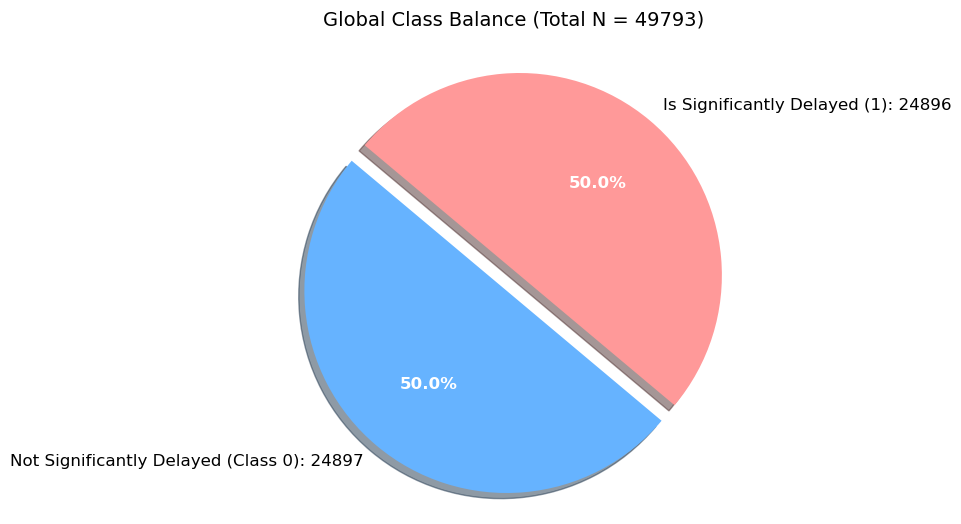

Negative Count: 24897
Positive Count: 24896
Class balance: 1.0000401670951158
Recommended scale_pos_weight: 1.00


In [ ]:
# 2. Extract counts (0 is Negative, 1 is Positive)
neg_count = dataset_cleaned_df[dataset_cleaned_df['target_binary'] == 0].shape[0]
pos_count = dataset_cleaned_df[dataset_cleaned_df['target_binary'] == 1].shape[0]

# Calculate percentages
total_count = neg_count + pos_count
neg_pct = (neg_count / total_count) * 100
pos_pct = (pos_count / total_count) * 100


# 1. Calculate counts and percentages
counts = dataset_cleaned_df['target_binary'].value_counts()
total = counts.sum()

# Create labels that include the raw count: e.g., "On-Time (0): 950"
labels = [f'{ "Not Significantly Delayed (Class 0)" if x == 0 else "Is Significantly Delayed (1)" }: {counts[x]}' for x in counts.index]
colors = ['#66b3ff', '#ff9999']

# 2. Plotting
plt.figure(figsize=(8, 6))
patches, texts, autotexts = plt.pie(
    counts, 
    labels=labels, 
    colors=colors, 
    autopct='%1.1f%%', 
    shadow=True, 
    startangle=140, 
    explode=(0.1, 0) if len(counts) > 1 else None,
    textprops={'fontsize': 12}
)

# Style the percentage text inside the pie to be bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_weight('bold')

plt.title(f'Global Class Balance (Total N = {total})', fontsize=14, pad=20)
plt.axis('equal') 

# # 3. Save to path
# plt.savefig(f'{media_folder}/class_balance.png', bbox_inches='tight', dpi=300)
plt.show()


# 3. Store the ratio
# scale_pos_weight acts as a multiplier for the positive class gradient
if pos_count > 0:
    scale_pos_weight_value_train = neg_count / pos_count
else:
    scale_pos_weight_value_train = 1.0  # Fallback to neutral weight
    print("Warning: No positive instances found!")

print(f"Negative Count: {neg_count}")
print(f"Positive Count: {pos_count}")
print(f"Class balance: {neg_count / pos_count}")
print(f"Recommended scale_pos_weight: {scale_pos_weight_value_train:.2f}")

# Prep Data (subset/fulll)

In [ ]:
# 1. Load the full dataset
df = pd.read_parquet(final_dataset_for_training_path)
if subset_dataset:
    data_df = df[(df['year'] >= 2024) & (df['month'] < 12)].copy()
    print(f"✅ Subset loaded. Rows: {len(data_df)}")
    print(f"Unique Years: {data_df['year'].unique()} | Unique Months: {data_df['month'].unique()}")
else:
    data_df = df.copy()
    print(f"✅ Full data loaded. Rows: {len(data_df)}")
    print(f"Unique Years: {data_df['year'].unique()} | Unique Months: {data_df['month'].unique()}")

✅ Full data loaded. Rows: 49793
Unique Years: [2024 2020 2022 2023 2019 2021] | Unique Months: [ 4  3 10 11  6  9  2 12  8  7  5  1]


# 1_Class_Base ORIGINAL

In [ ]:
# import sys
# import random
# import datetime
# import shap

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import scipy.stats as ss

# from datetime import date
# from tqdm import tqdm
# from imblearn.under_sampling import RandomUnderSampler
# from xgboost import XGBClassifier
# from sklearn.metrics import confusion_matrix, balanced_accuracy_score, mean_squared_error, r2_score, mean_absolute_error

# sys.path.append('src')
# from plot_style import *

# def get_trajectory_slice(data, f_train_e=0.7, seed=30):
#     df = data
#     trajectories = list(set(df[['source', 'target']].itertuples(index=False, name=None)))
#     random.seed(seed)
#     train_size = int(f_train_e * len(trajectories))
#     random.shuffle(trajectories)
#     train_trajectories = set(trajectories[:train_size])
#     test_trajectories = set(trajectories[train_size:])
    
#     df_train = df.loc[df[['source', 'target']].apply(tuple, axis=1).isin(train_trajectories)].copy()
#     df_test = df.loc[df[['source', 'target']].apply(tuple, axis=1).isin(test_trajectories)].copy()
    
#     return df_train, df_test

# def df_to_XY(df, features, target='Significant Delay'):
#     X = df.loc[:, features].to_numpy()
#     y = df.loc[:, target].to_numpy()
#     return X, y

# def simultaneous_test(df_train, df_test, features, best_params, save=True, name=None):
#     if name is None:
#         name = ''.join([w[0] for w in features]) + '_simultaneous'
#     else:
#         name = name + '_simultaneous'
    
#     year_month_list = sorted(df_train['YearMonth'].unique())
#     res_df_test = df_test.copy()
#     res_df_test['simultaneous_pred'] = np.nan
#     res_df_test['simultaneous_null'] = np.nan
    
#     for year_month in tqdm(year_month_list):
#         X_train, y_train = df_to_XY(df_train[df_train['YearMonth'] == year_month], features)
#         ros = RandomUnderSampler()
#         X_train, y_train = ros.fit_resample(X_train, y_train)
#         X_test, y_test = df_to_XY(df_test[df_test['YearMonth'] == year_month], features)
        
#         y_train_null = y_train.copy()
#         np.random.shuffle(y_train_null)
        
#         model = XGBClassifier(**best_params)
#         model.fit(X_train, y_train)
#         model_null = XGBClassifier(**best_params)
#         model_null.fit(X_train, y_train_null)
        
#         y_pred = model.predict(X_test)
#         y_pred_null = model_null.predict(X_test)
        
#         res_df_test.loc[res_df_test['YearMonth'] == year_month, 'simultaneous_pred'] = y_pred
#         res_df_test.loc[res_df_test['YearMonth'] == year_month, 'simultaneous_null'] = y_pred_null
    
#     if save:
#         res_df_test.to_csv(f'./results_XGB/{name}.csv', index=False)
    
#     return res_df_test

# def nonsimultaneous_test(df_train, df_test, features, best_params, save=True, name=None):
#     if name is None:
#         name = ''.join([w[0] for w in features]) + '_nonsimultaneous'
#     else:
#         name = name + '_nonsimultaneous'
    
#     year_month_list = sorted(df_test['YearMonth'].unique())
#     preds = []
    
#     for year_month_train in tqdm(year_month_list):
#         X_train, y_train = df_to_XY(df_train[df_train['YearMonth'] == year_month_train], features)
#         ros = RandomUnderSampler()
#         X_train, y_train = ros.fit_resample(X_train, y_train)
        
#         y_train_null = y_train.copy()
#         np.random.shuffle(y_train_null)
        
#         model = XGBClassifier(**best_params)
#         model.fit(X_train, y_train)
#         model_null = XGBClassifier(**best_params)
#         model_null.fit(X_train, y_train_null)
        
#         for year_month_test in year_month_list:
#             if year_month_test < year_month_train:
#                 continue
#             X_test, y_test = df_to_XY(df_test[df_test['YearMonth'] == year_month_test], features)
#             y_pred = model.predict(X_test)
#             y_null = model_null.predict(X_test)
#             preds.append([year_month_train, year_month_test, y_test, y_pred, y_null])
    
#     if save:
#         import pickle
#         with open(f'./results_XGB/{name}.pkl', 'wb') as f:
#             pickle.dump(preds, f)
    
#     return preds

# def all_shap_values(df_train, df_test, features, best_params, save=True, name=None):
#     if name is None:
#         name = ''.join([w[0] for w in features]) + '_SHAP'
#     else:
#         name = name + '_SHAP'
    
#     def get_temporal_order(shap_list):
#         importance_array = []
#         for shap_values in shap_list:
#             array = -np.abs(shap_values).mean(axis=0)
#             ranks = ss.rankdata(array)
#             importance_array.append(ranks)
#         return np.array(importance_array)

#     shap_values_list = []
#     test_list = []
#     year_month_list = sorted(df_test['YearMonth'].unique())
    
#     for year_month in tqdm(year_month_list):
#         X_train, y_train = df_to_XY(df_train[df_train['YearMonth'] == year_month], features)
#         ros = RandomUnderSampler()
#         X_train, y_train = ros.fit_resample(X_train, y_train)
#         X_test, y_test = df_to_XY(df_test[df_test['YearMonth'] == year_month], features)
        
#         model = XGBClassifier(**best_params)
#         model.fit(X_train, y_train)
#         explainer = shap.TreeExplainer(model)
#         shap_values = explainer.shap_values(X_test)
        
#         test_list.append(pd.DataFrame(X_test, columns=features))
#         shap_values_list.append(shap_values)
    
#     if save:
#         import pickle
#         with open(f'./results_XGB/{name}.pkl', 'wb') as f:
#             pickle.dump((test_list, year_month_list, shap_values_list), f)
    
#     return test_list, year_month_list, shap_values_list

# def BTF(train, test):
#     name = 'NS_Classification_BTF'
#     features = ['CN', 'SA', 'JA', 'SO', 'HPI', 'HDI', 'LHNI', 'PA', 'AA', 'RA', 'LPI']
#     simultaneous_test(train, test, features, best_params, name=name)
#     nonsimultaneous_test(train, test, features, best_params, name=name)
#     all_shap_values(train, test, features, best_params, name=name)

# def WTF(train, test):
#     name = 'NS_Classification_WTF'
#     features = ['weighted_CN', 'weighted_SA', 'weighted_JA', 'weighted_SO', 'weighted_HPI', 
#                 'weighted_HDI', 'weighted_LHNI', 'weighted_PA', 'weighted_AA', 'weighted_RA', 'weighted_LPI']
#     simultaneous_test(train, test, features, best_params, name=name)
#     nonsimultaneous_test(train, test, features, best_params, name=name)
#     all_shap_values(train, test, features, best_params, name=name)

# def NCM(train, test):
#     name = 'NS_Classification_NCM'
#     features = ['source_closeness', 'target_closeness', 'source_degree', 'target_degree', 'source_strength', 'target_strength']
#     simultaneous_test(train, test, features, best_params, name=name)
#     nonsimultaneous_test(train, test, features, best_params, name=name)
#     all_shap_values(train, test, features, best_params, name=name)

# if __name__ == "__main__":
#     global best_params
#     best_params = {'lambda': 0.5650701862593042, 'alpha': 0.0016650896783581535,
#                    'colsample_bytree': 1.0, 'subsample': 0.5, 'learning_rate': 0.009,
#                    'n_estimators': 625, 'objective': 'binary:logistic', 'max_depth': 5, 'min_child_weight': 6}

#     data_path = '/Users/merelkamper/Documents/MSc Data Science/Thesis/MSc_thesis_code/features/monthly_features_per_trajectory.csv'
#     data = pd.read_csv(data_path)
#     data['YearMonth'] = pd.to_datetime(data['YearMonth']).dt.to_period('M')
    
#     train, test = get_trajectory_slice(data)
#     BTF(train, test)
#     WTF(train, test)
#     NCM(train, test)

# 1_Class_Base ADAPTED

In [ ]:
if run_baseline:
    import sys
    import random
    import datetime
    import shap

    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import scipy.stats as ss

    from datetime import date
    from tqdm import tqdm
    from imblearn.under_sampling import RandomUnderSampler
    from xgboost import XGBClassifier
    from sklearn.metrics import confusion_matrix, balanced_accuracy_score, mean_squared_error, r2_score, mean_absolute_error

    sys.path.append('src')
    # from plot_style import *

    def get_trajectory_slice(data, f_train_e=0.7, seed=RANDOM_SEED):
        df = data
        trajectories = list(set(df[['source', 'target']].itertuples(index=False, name=None)))
        random.seed(seed)
        train_size = int(f_train_e * len(trajectories))
        random.shuffle(trajectories)
        train_trajectories = set(trajectories[:train_size])
        test_trajectories = set(trajectories[train_size:])
        
        df_train = df.loc[df[['source', 'target']].apply(tuple, axis=1).isin(train_trajectories)].copy()
        df_test = df.loc[df[['source', 'target']].apply(tuple, axis=1).isin(test_trajectories)].copy()
        
        return df_train, df_test

    def df_to_XY(df, features, target='target_binary'):
        X = df.loc[:, features].to_numpy()
        y = df.loc[:, target].to_numpy()
        return X, y

    def simultaneous_test(df_train, df_test, features, best_params, save=True, name=None):
        if name is None:
            name = ''.join([w[0] for w in features]) + '_simultaneous'
        else:
            name = name + '_simultaneous'
        
        year_month_list = sorted(df_train['YearMonth'].unique())
        res_df_test = df_test.copy()
        res_df_test['simultaneous_pred'] = np.nan
        res_df_test['simultaneous_null'] = np.nan
        
        for year_month in tqdm(year_month_list):
            X_train, y_train = df_to_XY(df_train[df_train['YearMonth'] == year_month], features)
            ros = RandomUnderSampler()
            X_train, y_train = ros.fit_resample(X_train, y_train)
            X_test, y_test = df_to_XY(df_test[df_test['YearMonth'] == year_month], features)
            
            y_train_null = y_train.copy()
            np.random.shuffle(y_train_null)
            
            model = XGBClassifier(**best_params)
            model.fit(X_train, y_train)
            model_null = XGBClassifier(**best_params)
            model_null.fit(X_train, y_train_null)
            
            y_pred = model.predict(X_test)
            y_pred_null = model_null.predict(X_test)
            
            res_df_test.loc[res_df_test['YearMonth'] == year_month, 'simultaneous_pred'] = y_pred
            res_df_test.loc[res_df_test['YearMonth'] == year_month, 'simultaneous_null'] = y_pred_null
        
        if save:
            res_df_test.to_csv(f'{results_xgb}/{name}.csv', index=False)
        
        return res_df_test

    def nonsimultaneous_test(df_train, df_test, features, best_params, save=True, name=None):
        if name is None:
            name = ''.join([w[0] for w in features]) + '_nonsimultaneous'
        else:
            name = name + '_nonsimultaneous'
        
        year_month_list = sorted(df_test['YearMonth'].unique())
        preds = []
        
        for year_month_train in tqdm(year_month_list):
            X_train, y_train = df_to_XY(df_train[df_train['YearMonth'] == year_month_train], features)
            ros = RandomUnderSampler()
            X_train, y_train = ros.fit_resample(X_train, y_train)
            
            y_train_null = y_train.copy()
            np.random.shuffle(y_train_null)
            
            model = XGBClassifier(**best_params)
            model.fit(X_train, y_train)
            model_null = XGBClassifier(**best_params)
            model_null.fit(X_train, y_train_null)
            
            for year_month_test in year_month_list:
                if year_month_test < year_month_train:
                    continue
                X_test, y_test = df_to_XY(df_test[df_test['YearMonth'] == year_month_test], features)
                y_pred = model.predict(X_test)
                y_null = model_null.predict(X_test)
                preds.append([year_month_train, year_month_test, y_test, y_pred, y_null])
        
        if save:
            import pickle
            with open(f'{results_xgb}/{name}.pkl', 'wb') as f:
                pickle.dump(preds, f)
        
        return preds

    # Migrate into nonsim testing?, plot_shap_values, shap on train set
    def all_shap_values(df_train, df_test, features, best_params, save=True, name=None):
        if name is None:
            name = ''.join([w[0] for w in features]) + '_SHAP'
        else:
            name = name + '_SHAP'
        # 1. Define the save directory and create it if it doesn't exist
        save_dir = f"{results_xgb}/SHAP_plots/{name}"
        os.makedirs(save_dir, exist_ok=True)

        #unused
        def get_temporal_order(shap_list):
            importance_array = []
            for shap_values in shap_list:
                array = -np.abs(shap_values).mean(axis=0)
                ranks = ss.rankdata(array)
                importance_array.append(ranks)
            return np.array(importance_array)

        shap_values_list = []
        test_list = []
        year_month_list = sorted(df_test['YearMonth'].unique())
        
        for year_month in tqdm(year_month_list):
            X_train, y_train = df_to_XY(df_train[df_train['YearMonth'] == year_month], features)
            ros = RandomUnderSampler()
            X_train, y_train = ros.fit_resample(X_train, y_train)
            X_test, y_test = df_to_XY(df_test[df_test['YearMonth'] == year_month], features)
            
            # FULL MODEL
            model = XGBClassifier(**best_params)
            model.fit(X_train, y_train)

            # -------------SHAP EXPLANATAIONS-------------------
            # Utilizing shap easier new api explainer object
            if not isinstance(X_test, pd.DataFrame):
                X_test_shap = pd.DataFrame(X_test, columns=features)

            # SAMPLING FOR SHAP (brents)
            if shap_sample:
                X_test_shap = X_test_shap.sample(n=min(1000, len(X_test)), random_state=RANDOM_SEED)
                
            clean_year_month = year_month.strftime('%Y-%m')

            explainer = shap.TreeExplainer(model)
            shap_explanation = explainer(X_test_shap.values)
            shap_values = shap_explanation.values
            mean_abs_shap = shap_explanation.abs.mean(0).values

            test_list.append(pd.DataFrame(X_test, columns=features))
            shap_values_list.append(shap_values)

            model_type = 'XGBoost'
            threshold = 0.5
            shap_df = pd.DataFrame({
                'feature': features, # Or whatever your DuckDB feature list variable is called
                'mean_shap': mean_abs_shap
            })
            try:
                # SHAP Summary Plot
                plt.figure()
                shap.summary_plot(shap_values, X_test_shap, feature_names=features, max_display=20, show=False)
                plt.title(f"SHAP Summary Plot for {model_type.replace('_', ' ').title()} ({clean_year_month})")
                plt.tight_layout()
                summary_filename = f"{save_dir}/{clean_year_month}_{model_type}_{name}_summary.png"
                plt.savefig(summary_filename, dpi=300, bbox_inches='tight')
                # plt.show()
                plt.close()

                # Bar plot of mean SHAP values
                plt.figure(figsize=(10, 6))
                shap_df_sorted = shap_df.sort_values('mean_shap', ascending=False)
                plt.bar(shap_df_sorted['feature'], shap_df_sorted['mean_shap'])
                plt.axhline(y=threshold, color='r', linestyle='--', label=f'Threshold = {threshold}')
                plt.xticks(rotation=45, ha='right')
                plt.xlabel('Features')
                plt.ylabel('Mean Absolute SHAP Value')
                plt.title(f"Mean Absolute SHAP Values for {model_type.replace('_', ' ').title()} ({clean_year_month})")
                plt.legend()
                plt.tight_layout()
                bar_filename = f"{save_dir}/{clean_year_month}_{model_type}_{name}_bar.png"
                plt.savefig(bar_filename, dpi=300, bbox_inches='tight')
                # plt.show()
                plt.close()
            except Exception as e:
                # If anything goes wrong, catch the error, print it, and keep the loop alive
                print(f"⚠️ WARNING: Failed to generate SHAP plots for {clean_year_month}. Skipping visualization.")
                print(f"Error Details: {e}")
                
                plt.close('all')
        
        if save:
            import pickle
            with open(f'{results_xgb}/{name}.pkl', 'wb') as f:
                pickle.dump((test_list, year_month_list, shap_values_list), f)
        
        return test_list, year_month_list, shap_values_list


    def TOP(train, test):
        name = 'NS_I_TOP'
        features = topology_features
        simultaneous_test(train, test, features, best_params, name=name)
        nonsimultaneous_test(train, test, features, best_params, name=name)
        if shap_analysis:
            all_shap_values(train, test, features, best_params, name=name)

    def WGT(train, test):
        name = 'NS_I_WGT'
        features = topology_weight_feature
        simultaneous_test(train, test, features, best_params, name=name)
        nonsimultaneous_test(train, test, features, best_params, name=name)
        if shap_analysis:
            all_shap_values(train, test, features, best_params, name=name)

    def WTH(train, test):
        name = 'NS_I_WTH'
        features = weather_features
        simultaneous_test(train, test, features, best_params, name=name)
        nonsimultaneous_test(train, test, features, best_params, name=name)
        if shap_analysis:
            all_shap_values(train, test, features, best_params, name=name)

    def OPS(train, test):
        name = 'NS_I_OPS'
        features = operational_features
        simultaneous_test(train, test, features, best_params, name=name)
        nonsimultaneous_test(train, test, features, best_params, name=name)
        if shap_analysis:
            all_shap_values(train, test, features, best_params, name=name)

    # def CAL(train, test):
    # 	name = 'NS_I_CAL'
    # 	features = calendar_features
    # 	simultaneous_test(train, test, features, best_params, name=name)
    # 	nonsimultaneous_test(train, test, features, best_params, name=name)
    # 	if shap_analysis:
    # 		all_shap_values(train, test, features, best_params, name=name)

    def TW(train, test):
        name = 'NS_C_TW'
        features = topology_features + topology_weight_feature
        simultaneous_test(train, test, features, best_params, name=name)
        nonsimultaneous_test(train, test, features, best_params, name=name)
        if shap_analysis:
            all_shap_values(train, test, features, best_params, name=name)

    # def TWC(train, test):
    # 	name = 'NS_C_TWC'
    # 	features = topology_features + topology_weight_feature + calendar_features
    # 	simultaneous_test(train, test, features, best_params, name=name)
    # 	nonsimultaneous_test(train, test, features, best_params, name=name)
    # 	if shap_analysis:
    # 		all_shap_values(train, test, features, best_params, name=name)

    def TWCW(train, test):
        name = 'NS_C_TWCW'
        features = topology_features + topology_weight_feature + calendar_features + weather_features
        simultaneous_test(train, test, features, best_params, name=name)
        nonsimultaneous_test(train, test, features, best_params, name=name)
        if shap_analysis:
            all_shap_values(train, test, features, best_params, name=name)

    def TWCO(train, test):
        name = 'NS_C_TWCO'
        features = topology_features + topology_weight_feature + calendar_features + operational_features
        simultaneous_test(train, test, features, best_params, name=name)
        nonsimultaneous_test(train, test, features, best_params, name=name)
        if shap_analysis:
            all_shap_values(train, test, features, best_params, name=name)

    def ALLF(train, test):
        name = 'NS_C_ALLF'
        features = topology_features + topology_weight_feature + calendar_features + operational_features + weather_features
        simultaneous_test(train, test, features, best_params, name=name)
        nonsimultaneous_test(train, test, features, best_params, name=name)
        if shap_analysis:
            all_shap_values(train, test, features, best_params, name=name)

    if __name__ == "__main__":
        global best_params
        # best_params = {'lambda': 0.5650701862593042, 'alpha': 0.0016650896783581535,
        # 			'colsample_bytree': 1.0, 'subsample': 0.5, 'learning_rate': 0.009,
        # 			'n_estimators': 625, 'objective': 'binary:logistic', 'max_depth': 5, 'min_child_weight': 6}
        best_params = {'objective': 'binary:logistic', 'booster': 'gbtree'}

        data = data_df
        data['YearMonth'] = pd.to_datetime(data['YearMonth'])    
        train, test = get_trajectory_slice(data)
        # ## Individual sets
        TOP(train, test)
        WGT(train, test)
        WTH(train, test)
        OPS(train, test)
        # CAL(train, test)

        TW(train, test)

        ## Combined
        # TWC(train, test)
        TWCW(train, test)
        TWCO(train, test)
        ALLF(train, test)

# B_Class ORIGINAL

In [ ]:
# import sys
# import random
# import logging
# import numpy as np
# import pandas as pd
# from tqdm import tqdm
# from xgboost import XGBClassifier
# from sklearn.preprocessing import StandardScaler
# from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, RandomForestClassifier
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.linear_model import RidgeClassifier, LogisticRegression
# from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
# from sklearn.model_selection import RandomizedSearchCV
# from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score

# # Configure logging
# logging.basicConfig(level=logging.INFO)

# # Load data
# data_path = '/Users/merelkamper/Documents/MSc Data Science/Thesis/MSc_thesis_code/features/monthly_features_per_trajectory.csv'
# data = pd.read_csv(data_path)

# # Time-based split function to ensure each month has data in both sets
# def time_based_split(data, train_ratio=0.7):
#     train_data = []
#     test_data = []

#     for period in data['YearMonth'].unique():
#         period_data = data[data['YearMonth'] == period]
#         train_sample_count = int(len(period_data) * train_ratio)
        
#         period_train = period_data.sample(train_sample_count, random_state=42)
#         period_test = period_data.drop(period_train.index)
        
#         train_data.append(period_train)
#         test_data.append(period_test)

#     df_train = pd.concat(train_data)
#     df_test = pd.concat(test_data)

#     return df_train, df_test

# train, test = time_based_split(data)

# # Define the feature sets
# feature_sets = {
#     'TF': ['CN', 'SA', 'JA', 'SO', 'HPI', 'HDI', 'LHNI', 'PA', 'AA', 'RA', 'LPI'],
#     'WTF': ['weighted_CN', 'weighted_SA', 'weighted_JA', 'weighted_SO', 'weighted_HPI', 'weighted_HDI', 'weighted_LHNI', 'weighted_PA', 'weighted_AA', 'weighted_RA', 'weighted_LPI'],
#     'NCM': ['source_closeness', 'target_closeness', 'source_degree', 'target_degree', 'source_strength', 'target_strength']
# }

# # Define model training function
# def train_model(X_train, y_train, classifier, param_grid=None):
#     scaler = StandardScaler()
#     X_train = scaler.fit_transform(X_train)
    
#     if param_grid:
#         randomized_search = RandomizedSearchCV(
#             classifier, 
#             param_distributions=param_grid, 
#             n_iter=10, 
#             scoring='balanced_accuracy', 
#             n_jobs=-1, 
#             cv=10, 
#             random_state=RANDOM_SEED)
#         randomized_search.fit(X_train, y_train)
#         best_classifier = randomized_search.best_estimator_
#     else:
#         classifier.fit(X_train, y_train)
#         best_classifier = classifier
        
#     return best_classifier, scaler

# # Define evaluation function
# def evaluate_classifier(y_true, y_pred, y_proba=None):
#     if len(y_true) == 0 or len(y_pred) == 0:
#         return np.nan, np.nan, np.nan  # Return NaN if arrays are empty

#     balanced_accuracy = balanced_accuracy_score(y_true, y_pred)
#     f1 = f1_score(y_true, y_pred)
#     if y_proba is not None and len(y_proba) == len(y_true):
#         auc = roc_auc_score(y_true, y_proba)
#     else:
#         auc = np.nan  # Return NaN if probabilities are not available or not the same length
#     return balanced_accuracy, f1, auc

# # Define function to convert dataframe to X, y
# def df_to_XY(df, features, target='Significant Delay'):
#     X = df[features].to_numpy()
#     y = df[target].astype(int).to_numpy()
#     return X, y

# # Define Simultaneous Testing Function
# def simultaneous_test(df_train, df_test, features, classifier, param_grid=None, name=None):
#     year_month_list = df_train['YearMonth'].unique()
#     res_df_test = df_test.copy()
#     res_df_test[f'{name}_pred'] = np.nan
#     res_df_test[f'{name}_proba'] = np.nan

#     all_y_true = []
#     all_y_pred = []
#     all_y_proba = []

#     for year_month in tqdm(year_month_list):
#         train_subset = df_train[df_train['YearMonth'] == year_month]
#         test_subset = df_test[df_test['YearMonth'] == year_month]

#         X_train, y_train = df_to_XY(train_subset, features)
#         X_test, y_test = df_to_XY(test_subset, features)

#         if len(X_train) == 0 or len(X_test) == 0:
#             logging.warning(f"Skipping YearMonth {year_month} due to empty training or testing data.")
#             continue

#         model, scaler = train_model(X_train, y_train, classifier, param_grid)
#         X_test = scaler.transform(X_test)

#         y_pred = model.predict(X_test)
#         y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

#         res_df_test.loc[res_df_test['YearMonth'] == year_month, f'{name}_pred'] = y_pred
#         if y_proba is not None:
#             res_df_test.loc[res_df_test['YearMonth'] == year_month, f'{name}_proba'] = y_proba

#         # Store intermediate results
#         all_y_true.extend(y_test)
#         all_y_pred.extend(y_pred)
#         if y_proba is not None:
#             all_y_proba.extend(y_proba)

#     if len(all_y_true) > 0 and len(all_y_pred) > 0:
#         if all_y_proba:
#             balanced_accuracy, f1, auc = evaluate_classifier(np.array(all_y_true), np.array(all_y_pred), np.array(all_y_proba))
#         else:
#             balanced_accuracy, f1, auc = evaluate_classifier(np.array(all_y_true), np.array(all_y_pred))
#     else:
#         balanced_accuracy, f1, auc = np.nan, np.nan, np.nan

#     print(f"{name} - Balanced Accuracy: {balanced_accuracy:.4f}, F1 Score: {f1:.4f}, AUC: {auc:.4f}")

#     res_df_test.to_csv(f'/Users/merelkamper/Documents/MSc Data Science/Thesis/MSc_thesis_code/results_classifiers/{name}_results.csv', index=False)
#     return res_df_test, all_y_true, all_y_pred, all_y_proba

# # Define Non-Simultaneous Testing Function
# def nonsimultaneous_test(df_train, df_test, features, classifier, param_grid=None, name=None):
#     year_month_list = df_train['YearMonth'].unique()
#     results = []

#     for i, train_period in enumerate(tqdm(year_month_list)):
#         train_subset = df_train[df_train['YearMonth'] == train_period]
#         X_train, y_train = df_to_XY(train_subset, features)

#         if len(y_train) == 0:
#             logging.warning(f"Skipping train_period {train_period} due to empty training data.")
#             continue

#         model, scaler = train_model(X_train, y_train, classifier, param_grid)

#         for test_period in year_month_list[i:]:
#             test_subset = df_test[df_test['YearMonth'] == test_period]
#             X_test, y_test = df_to_XY(test_subset, features)

#             if len(y_test) == 0:
#                 logging.warning(f"Skipping test_period {test_period} due to empty testing data.")
#                 continue

#             X_test = scaler.transform(X_test)
#             y_pred = model.predict(X_test)
#             y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
#             results.append((train_period, test_period, y_test.tolist(), y_pred.tolist(), y_proba.tolist() if y_proba is not None else []))

#     results_df = pd.DataFrame(results, columns=['TrainPeriod', 'TestPeriod', 'TrueLabels', 'Predictions', 'Probabilities'])
#     results_df.to_csv(f'/Users/merelkamper/Documents/MSc Data Science/Thesis/MSc_thesis_code/results_classifiers/{name}_nonsimultaneous_results.csv', index=False)

#     all_y_true = [label for result in results for label in result[2]]
#     all_y_pred = [pred for result in results for pred in result[3]]
#     all_y_proba = [proba for result in results for proba in result[4]]

#     if len(all_y_true) > 0 and len(all_y_pred) > 0:
#         if all_y_proba:
#             balanced_accuracy, f1, auc = evaluate_classifier(np.array(all_y_true), np.array(all_y_pred), np.array(all_y_proba))
#         else:
#             balanced_accuracy, f1, auc = evaluate_classifier(np.array(all_y_true), np.array(all_y_pred))
#     else:
#         balanced_accuracy, f1, auc = np.nan, np.nan, np.nan

#     print(f"{name} - Balanced Accuracy: {balanced_accuracy:.4f}, F1 Score: {f1:.4f}, AUC: {auc:.4f}")

#     return results_df, all_y_true, all_y_pred, all_y_proba

# # Define parameter grids for each classifier
# param_grids = {
#     'GradientBoostingClassifier': {
#         'n_estimators': [50, 100, 200, 300],
#         'learning_rate': [0.01, 0.05, 0.1, 0.2],
#         'max_depth': [3, 5, 7, 9],
#         'min_samples_split': [2, 5, 10],
#         'min_samples_leaf': [1, 2, 4],
#         'max_features': ['sqrt', 'log2']
#     },
#     'AdaBoostClassifier': {
#         'n_estimators': [50, 100, 200, 400],
#         'learning_rate': [0.01, 0.1, 0.5, 1.0]
#     },
#     'LogisticRegression': {
#         'C': [0.001, 0.01, 0.1, 1, 10, 100],
#         'penalty': ['l1', 'l2', 'elasticnet'],
#         'solver': ['liblinear', 'saga']
#     },
#     'RandomForestClassifier': {
#         'n_estimators': [100, 200, 500, 1000],
#         'max_features': ['auto', 'sqrt', 'log2'],
#         'max_depth': [10, 20, 30, None],
#         'min_samples_split': [2, 5, 10],
#         'min_samples_leaf': [1, 2, 4],
#         'bootstrap': [True, False]
#     },
#     'DecisionTreeClassifier': {
#         'max_features': ['auto', 'sqrt', 'log2'],
#         'max_depth': [10, 20, 30, None],
#         'min_samples_split': [2, 5, 10],
#         'min_samples_leaf': [1, 2, 4],
#         'criterion': ['gini', 'entropy']
#     }
# }

# # Specific parameters for XGBoost
# best_params = {'lambda': 0.5650701862593042, 'alpha': 0.0016650896783581535,
#            'colsample_bytree': 1.0, 'subsample': 0.5, 'learning_rate': 0.009,
#            'n_estimators': 625, 'objective':'binary:logistic', 'max_depth': 5, 'min_child_weight': 6}

# # Include classifiers dictionary with XGBoost
# classifiers = {
#     'GradientBoostingClassifier': GradientBoostingClassifier(),
#     'AdaBoostClassifier': AdaBoostClassifier(),
#     'LogisticRegression': LogisticRegression(),
#     'RandomForestClassifier': RandomForestClassifier(),
#     'DecisionTreeClassifier': DecisionTreeClassifier(),
#     'XGBClassifier': XGBClassifier(**best_params),
# }

# # Run simultaneous and non-simultaneous testing for each classifier and each feature set
# for feature_set_name, feature_set in feature_sets.items():
#     for name, classifier in classifiers.items():
#         param_grid = param_grids.get(name, None)
#         print(f"Running simultaneous test for {name} with feature set {feature_set_name}...")
#         simultaneous_test(train, test, feature_set, classifier, param_grid, f'{name}_{feature_set_name}')
        
#         print(f"Running non-simultaneous test for {name} with feature set {feature_set_name}...")
#         nonsimultaneous_test(train, test, feature_set, classifier, param_grid, f'{name}_{feature_set_name}')

# B_Class ADAPTED

Monthly balance using class_weights for lr,rf,xgb,lgbm and scale_pos_weight (dynamic) for xgb instead of ROS

In [ ]:
if run_new:
    import sys
    import random
    import logging
    import numpy as np
    import pandas as pd
    from tqdm import tqdm
    from xgboost import XGBClassifier
    from sklearn.preprocessing import StandardScaler
    from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, RandomForestClassifier
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.linear_model import RidgeClassifier, LogisticRegression
    from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
    from sklearn.model_selection import RandomizedSearchCV
    from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score

    # Configure logging
    logging.basicConfig(level=logging.INFO)

    # Load data
    data = data_df

    # Time-based split function to ensure each month has data in both sets
    def time_based_split(data, train_ratio=0.7):
        train_data = []
        test_data = []

        for period in data['YearMonth'].unique():
            period_data = data[data['YearMonth'] == period]
            train_sample_count = int(len(period_data) * train_ratio)
            
            period_train = period_data.sample(train_sample_count, random_state=RANDOM_SEED)
            period_test = period_data.drop(period_train.index)
            
            train_data.append(period_train)
            test_data.append(period_test)

        df_train = pd.concat(train_data)
        df_test = pd.concat(test_data)

        return df_train, df_test

    train, test = time_based_split(data)

    # Define the feature sets
    feature_sets = {
        'TOP': topology_features,
        'WGT': topology_weight_feature,
        'WTH': weather_features,
        'OPS': operational_features,
        # 'CAL': calendar_features,

        'TW':  topology_features + topology_weight_feature,
        
        # Combined feature sets 
        # 'TWC':  topology_features + topology_weight_feature + calendar_features,
        'TWCW': topology_features + topology_weight_feature + calendar_features + weather_features,
        'TWCO': topology_features + topology_weight_feature + calendar_features + operational_features,
        'ALLF': topology_features + topology_weight_feature + calendar_features + operational_features + weather_features
    }

    # Define model training function
    def train_model(X_train, y_train, classifier, param_grid=None):
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        
        # Dynamically calculate and set scale_pos_weight for XGBoost
        if isinstance(classifier, XGBClassifier) and balanced_class_weights:
            neg_count = np.sum(y_train == 0)
            pos_count = np.sum(y_train == 1)
            
            if pos_count > 0:
                spw = neg_count / pos_count
                classifier.set_params(scale_pos_weight=spw)
                logging.info(f" Set XGBoost scale_pos_weight to {spw:.2f}")
                
        if param_grid:
            randomized_search = RandomizedSearchCV(
                classifier, 
                param_distributions=param_grid, 
                n_iter=10, 
                scoring='balanced_accuracy', 
                n_jobs=-1, 
                cv=10, 
                random_state=RANDOM_SEED)
            randomized_search.fit(X_train, y_train)
            best_classifier = randomized_search.best_estimator_
        else:
            classifier.fit(X_train, y_train)
            best_classifier = classifier
            
        return best_classifier, scaler

    # Define evaluation function
    def evaluate_classifier(y_true, y_pred, y_proba=None):
        if len(y_true) == 0 or len(y_pred) == 0:
            return np.nan, np.nan, np.nan  # Return NaN if arrays are empty

        balanced_accuracy = balanced_accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        if y_proba is not None and len(y_proba) == len(y_true):
            auc = roc_auc_score(y_true, y_proba)
        else:
            auc = np.nan  # Return NaN if probabilities are not available or not the same length
        return balanced_accuracy, f1, auc

    # Define function to convert dataframe to X, y
    def df_to_XY(df, features, target='target_binary'):
        X = df[features].to_numpy()
        y = df[target].astype(int).to_numpy()
        return X, y

    # Define Simultaneous Testing Function
    def simultaneous_test(df_train, df_test, features, classifier, param_grid=None, name=None):
        year_month_list = df_train['YearMonth'].unique()
        res_df_test = df_test.copy()
        res_df_test[f'{name}_pred'] = np.nan
        res_df_test[f'{name}_proba'] = np.nan

        all_y_true = []
        all_y_pred = []
        all_y_proba = []

        for year_month in tqdm(year_month_list):
            train_subset = df_train[df_train['YearMonth'] == year_month]
            test_subset = df_test[df_test['YearMonth'] == year_month]

            X_train, y_train = df_to_XY(train_subset, features)
            X_test, y_test = df_to_XY(test_subset, features)

            if len(X_train) == 0 or len(X_test) == 0:
                logging.warning(f"Skipping YearMonth {year_month} due to empty training or testing data.")
                continue

            model, scaler = train_model(X_train, y_train, classifier, param_grid)
            X_test = scaler.transform(X_test)

            y_pred = model.predict(X_test)
            y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

            res_df_test.loc[res_df_test['YearMonth'] == year_month, f'{name}_pred'] = y_pred
            if y_proba is not None:
                res_df_test.loc[res_df_test['YearMonth'] == year_month, f'{name}_proba'] = y_proba

            # Store intermediate results
            all_y_true.extend(y_test)
            all_y_pred.extend(y_pred)
            if y_proba is not None:
                all_y_proba.extend(y_proba)

        if len(all_y_true) > 0 and len(all_y_pred) > 0:
            if all_y_proba:
                balanced_accuracy, f1, auc = evaluate_classifier(np.array(all_y_true), np.array(all_y_pred), np.array(all_y_proba))
            else:
                balanced_accuracy, f1, auc = evaluate_classifier(np.array(all_y_true), np.array(all_y_pred))
        else:
            balanced_accuracy, f1, auc = np.nan, np.nan, np.nan

        print(f"{name} - Balanced Accuracy: {balanced_accuracy:.4f}, F1 Score: {f1:.4f}, AUC: {auc:.4f}")

        res_df_test.to_csv(f'{results_classifiers}/{name}_results.csv', index=False)
        return res_df_test, all_y_true, all_y_pred, all_y_proba

    # Define Non-Simultaneous Testing Function
    def nonsimultaneous_test(df_train, df_test, features, classifier, param_grid=None, name=None):
        year_month_list = df_train['YearMonth'].unique()
        results = []

        for i, train_period in enumerate(tqdm(year_month_list)):
            train_subset = df_train[df_train['YearMonth'] == train_period]
            X_train, y_train = df_to_XY(train_subset, features)

            if len(y_train) == 0:
                logging.warning(f"Skipping train_period {train_period} due to empty training data.")
                continue

            model, scaler = train_model(X_train, y_train, classifier, param_grid)

            for test_period in year_month_list[i:]:
                test_subset = df_test[df_test['YearMonth'] == test_period]
                X_test, y_test = df_to_XY(test_subset, features)

                if len(y_test) == 0:
                    logging.warning(f"Skipping test_period {test_period} due to empty testing data.")
                    continue

                X_test = scaler.transform(X_test)
                y_pred = model.predict(X_test)
                y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
                results.append((train_period, test_period, y_test.tolist(), y_pred.tolist(), y_proba.tolist() if y_proba is not None else []))

        results_df = pd.DataFrame(results, columns=['TrainPeriod', 'TestPeriod', 'TrueLabels', 'Predictions', 'Probabilities'])
        results_df.to_csv(f'{results_classifiers}/{name}_nonsimultaneous_results.csv', index=False)

        all_y_true = [label for result in results for label in result[2]]
        all_y_pred = [pred for result in results for pred in result[3]]
        all_y_proba = [proba for result in results for proba in result[4]]

        if len(all_y_true) > 0 and len(all_y_pred) > 0:
            if all_y_proba:
                balanced_accuracy, f1, auc = evaluate_classifier(np.array(all_y_true), np.array(all_y_pred), np.array(all_y_proba))
            else:
                balanced_accuracy, f1, auc = evaluate_classifier(np.array(all_y_true), np.array(all_y_pred))
        else:
            balanced_accuracy, f1, auc = np.nan, np.nan, np.nan

        print(f"{name} - Balanced Accuracy: {balanced_accuracy:.4f}, F1 Score: {f1:.4f}, AUC: {auc:.4f}")

        return results_df, all_y_true, all_y_pred, all_y_proba

    ## Define parameter grids for each classifier
    param_grids = {
        'LogisticRegression': {
            'C': [0.001, 0.01, 0.1, 1, 10, 100],
            'penalty': ['l1', 'l2', 'elasticnet'],
            'solver': ['liblinear', 'saga']
        },
        'RandomForestClassifier': {
            'n_estimators': [100, 200, 500, 1000],
            'max_features': ['auto', 'sqrt', 'log2'],
            'max_depth': [10, 20, 30, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'bootstrap': [True, False]
        },
        'XGBClassifier':{
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1, 0.3],      
            'n_estimators': [100, 200, 300],
            'subsample': [0.6, 0.8, 1.0],
            'colsample_bytree': [0.6, 0.8, 1.0],
        },
        'LGBMClassifier': {
            'max_depth': [-1, 3, 5, 7],          
            'num_leaves': [31, 50, 100], 
            'learning_rate': [0.01, 0.1, 0.3], 
            'n_estimators': [100, 200, 300],     
            'subsample': [0.6, 0.8, 1.0],        
            'colsample_bytree': [0.6, 0.8, 1.0],
        },
    # 	'GradientBoostingClassifier': {
    # 		'n_estimators': [50, 100, 200, 300],
    # 		'learning_rate': [0.01, 0.05, 0.1, 0.2],
    # 		'max_depth': [3, 5, 7, 9],
    # 		'min_samples_split': [2, 5, 10],
    # 		'min_samples_leaf': [1, 2, 4],
    # 		'max_features': ['sqrt', 'log2']
    # 	},
    # 	'AdaBoostClassifier': {
    # 		'n_estimators': [50, 100, 200, 400],
    # 		'learning_rate': [0.01, 0.1, 0.5, 1.0]
    # 	},
    # 	'DecisionTreeClassifier': {
    # 		'max_features': ['auto', 'sqrt', 'log2'],
    # 		'max_depth': [10, 20, 30, None],
    # 		'min_samples_split': [2, 5, 10],
    # 		'min_samples_leaf': [1, 2, 4],
    # 		'criterion': ['gini', 'entropy']
    # 	}
    }

    # # Specific parameters for XGBoost
    # best_params = {'lambda': 0.5650701862593042, 'alpha': 0.0016650896783581535,
    # 		'colsample_bytree': 1.0, 'subsample': 0.5, 'learning_rate': 0.009,
    # 		'n_estimators': 625, 'objective':'binary:logistic', 'max_depth': 5, 'min_child_weight': 6}

    # Include classifiers dictionary with XGBoost
    if balanced_class_weights:
        classifiers = {
            'LogisticRegression': LogisticRegression(random_state=RANDOM_SEED, class_weight='balanced', max_iter=1000),
            'RandomForestClassifier': RandomForestClassifier(random_state=RANDOM_SEED, class_weight='balanced', verbose=0),
            'XGBClassifier': XGBClassifier(random_state=RANDOM_SEED, objective='binary:logistic', verbosity=0), # Set scale pos weight dynamically in train_model
            'LGBMClassifier': LGBMClassifier(random_state=RANDOM_SEED, class_weight='balanced', objective='binary', verbose=-1)
            # 'GradientBoostingClassifier': GradientBoostingClassifier(),
            # 'AdaBoostClassifier': AdaBoostClassifier(),
            # 'DecisionTreeClassifier': DecisionTreeClassifier(),
        }
    else:
        classifiers = {
            'LogisticRegression': LogisticRegression(random_state=RANDOM_SEED, max_iter=1000),
            'RandomForestClassifier': RandomForestClassifier(random_state=RANDOM_SEED, verbose=0),
            'XGBClassifier': XGBClassifier(random_state=RANDOM_SEED, objective='binary:logistic', verbosity=0), # Set scale pos weight dynamically in train_model
            'LGBMClassifier': LGBMClassifier(random_state=RANDOM_SEED, objective='binary', verbose=-1)
            # 'GradientBoostingClassifier': GradientBoostingClassifier(),
            # 'AdaBoostClassifier': AdaBoostClassifier(),
            # 'DecisionTreeClassifier': DecisionTreeClassifier(),
        }

    # Run simultaneous and non-simultaneous testing for each classifier and each feature set
    for feature_set_name, feature_set in feature_sets.items():
        for name, classifier in classifiers.items():
            if search_param:
                param_grid = param_grids.get(name, None)
            else:
                param_grid = None
            print(f"Running simultaneous test for {name} with feature set {feature_set_name}...")
            simultaneous_test(train, test, feature_set, classifier, param_grid, f'{name}_{feature_set_name}')
            
            print(f"Running non-simultaneous test for {name} with feature set {feature_set_name}...")
            nonsimultaneous_test(train, test, feature_set, classifier, param_grid, f'{name}_{feature_set_name}')

Running simultaneous test for LogisticRegression with feature set TOP...



  0%|          | 0/72 [00:00<?, ?it/s]


 11%|█         | 8/72 [00:00<00:00, 73.40it/s]


 25%|██▌       | 18/72 [00:00<00:00, 84.14it/s]


 39%|███▉      | 28/72 [00:00<00:00, 87.36it/s]

...


 92%|█████████▏| 66/72 [00:13<00:00, 12.27it/s]


 94%|█████████▍| 68/72 [00:13<00:00, 13.72it/s]


 99%|█████████▊| 71/72 [00:13<00:00, 16.17it/s]


100%|██████████| 72/72 [00:14<00:00,  5.14it/s]

LGBMClassifier_ALLF - Balanced Accuracy: 0.5572, F1 Score: 0.5577, AUC: 0.5776


In [ ]:
if run_new:
    import sys
    import random
    import logging
    import numpy as np
    import pandas as pd
    from tqdm import tqdm
    from xgboost import XGBClassifier
    from sklearn.preprocessing import StandardScaler
    from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, RandomForestClassifier
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.linear_model import RidgeClassifier, LogisticRegression
    from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
    from sklearn.model_selection import RandomizedSearchCV
    from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score

    # Configure logging
    logging.basicConfig(level=logging.INFO)

    # Load data
    data = data_df

    # Time-based split function to ensure each month has data in both sets
    def time_based_split(data, train_ratio=0.7):
        train_data = []
        test_data = []

        for period in data['YearMonth'].unique():
            period_data = data[data['YearMonth'] == period]
            train_sample_count = int(len(period_data) * train_ratio)
            
            period_train = period_data.sample(train_sample_count, random_state=RANDOM_SEED)
            period_test = period_data.drop(period_train.index)
            
            train_data.append(period_train)
            test_data.append(period_test)

        df_train = pd.concat(train_data)
        df_test = pd.concat(test_data)

        return df_train, df_test

    train, test = time_based_split(data)

    # Define the feature sets
    feature_sets = {
        'TOP': topology_features,
        'WGT': topology_weight_feature,
        'WTH': weather_features,
        'OPS': operational_features,
        # 'CAL': calendar_features,

        'TW':  topology_features + topology_weight_feature,
        
        # Combined feature sets 
        # 'TWC':  topology_features + topology_weight_feature + calendar_features,
        'TWCW': topology_features + topology_weight_feature + calendar_features + weather_features,
        'TWCO': topology_features + topology_weight_feature + calendar_features + operational_features,
        'ALLF': topology_features + topology_weight_feature + calendar_features + operational_features + weather_features
    }

    # Define model training function
    def train_model(X_train, y_train, classifier, param_grid=None):
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        
        # Dynamically calculate and set scale_pos_weight for XGBoost
        if isinstance(classifier, XGBClassifier):
            neg_count = np.sum(y_train == 0)
            pos_count = np.sum(y_train == 1)
            
            if pos_count > 0:
                spw = neg_count / pos_count
                classifier.set_params(scale_pos_weight=spw)
                logging.info(f" Set XGBoost scale_pos_weight to {spw:.2f}")
                
        if param_grid:
            randomized_search = RandomizedSearchCV(
                classifier, 
                param_distributions=param_grid, 
                n_iter=10, 
                scoring='balanced_accuracy', 
                n_jobs=-1, 
                cv=10, 
                random_state=RANDOM_SEED)
            randomized_search.fit(X_train, y_train)
            best_classifier = randomized_search.best_estimator_
        else:
            classifier.fit(X_train, y_train)
            best_classifier = classifier
            
        return best_classifier, scaler

    # Define evaluation function
    def evaluate_classifier(y_true, y_pred, y_proba=None):
        if len(y_true) == 0 or len(y_pred) == 0:
            return np.nan, np.nan, np.nan  # Return NaN if arrays are empty

        balanced_accuracy = balanced_accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        if y_proba is not None and len(y_proba) == len(y_true):
            auc = roc_auc_score(y_true, y_proba)
        else:
            auc = np.nan  # Return NaN if probabilities are not available or not the same length
        return balanced_accuracy, f1, auc

    # Define function to convert dataframe to X, y
    def df_to_XY(df, features, target='target_binary'):
        X = df[features].to_numpy()
        y = df[target].astype(int).to_numpy()
        return X, y

    # Define Simultaneous Testing Function
    def simultaneous_test(df_train, df_test, features, classifier, param_grid=None, name=None):
        year_month_list = df_train['YearMonth'].unique()
        res_df_test = df_test.copy()
        res_df_test[f'{name}_pred'] = np.nan
        res_df_test[f'{name}_proba'] = np.nan

        all_y_true = []
        all_y_pred = []
        all_y_proba = []

        for year_month in tqdm(year_month_list):
            train_subset = df_train[df_train['YearMonth'] == year_month]
            test_subset = df_test[df_test['YearMonth'] == year_month]

            X_train, y_train = df_to_XY(train_subset, features)
            X_test, y_test = df_to_XY(test_subset, features)

            if len(X_train) == 0 or len(X_test) == 0:
                logging.warning(f"Skipping YearMonth {year_month} due to empty training or testing data.")
                continue

            model, scaler = train_model(X_train, y_train, classifier, param_grid)
            X_test = scaler.transform(X_test)

            y_pred = model.predict(X_test)
            y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

            res_df_test.loc[res_df_test['YearMonth'] == year_month, f'{name}_pred'] = y_pred
            if y_proba is not None:
                res_df_test.loc[res_df_test['YearMonth'] == year_month, f'{name}_proba'] = y_proba

            # Store intermediate results
            all_y_true.extend(y_test)
            all_y_pred.extend(y_pred)
            if y_proba is not None:
                all_y_proba.extend(y_proba)

        if len(all_y_true) > 0 and len(all_y_pred) > 0:
            if all_y_proba:
                balanced_accuracy, f1, auc = evaluate_classifier(np.array(all_y_true), np.array(all_y_pred), np.array(all_y_proba))
            else:
                balanced_accuracy, f1, auc = evaluate_classifier(np.array(all_y_true), np.array(all_y_pred))
        else:
            balanced_accuracy, f1, auc = np.nan, np.nan, np.nan

        print(f"{name} - Balanced Accuracy: {balanced_accuracy:.4f}, F1 Score: {f1:.4f}, AUC: {auc:.4f}")

        res_df_test.to_csv(f'{results_classifiers}/{name}_results.csv', index=False)
        return res_df_test, all_y_true, all_y_pred, all_y_proba

    # Define Non-Simultaneous Testing Function
    def nonsimultaneous_test(df_train, df_test, features, classifier, param_grid=None, name=None):
        year_month_list = df_train['YearMonth'].unique()
        results = []

        for i, train_period in enumerate(tqdm(year_month_list)):
            train_subset = df_train[df_train['YearMonth'] == train_period]
            X_train, y_train = df_to_XY(train_subset, features)

            if len(y_train) == 0:
                logging.warning(f"Skipping train_period {train_period} due to empty training data.")
                continue

            model, scaler = train_model(X_train, y_train, classifier, param_grid)

            for test_period in year_month_list[i:]:
                test_subset = df_test[df_test['YearMonth'] == test_period]
                X_test, y_test = df_to_XY(test_subset, features)

                if len(y_test) == 0:
                    logging.warning(f"Skipping test_period {test_period} due to empty testing data.")
                    continue

                X_test = scaler.transform(X_test)
                y_pred = model.predict(X_test)
                y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
                results.append((train_period, test_period, y_test.tolist(), y_pred.tolist(), y_proba.tolist() if y_proba is not None else []))

        results_df = pd.DataFrame(results, columns=['TrainPeriod', 'TestPeriod', 'TrueLabels', 'Predictions', 'Probabilities'])
        results_df.to_csv(f'{results_classifiers}/{name}_nonsimultaneous_results.csv', index=False)

        all_y_true = [label for result in results for label in result[2]]
        all_y_pred = [pred for result in results for pred in result[3]]
        all_y_proba = [proba for result in results for proba in result[4]]

        if len(all_y_true) > 0 and len(all_y_pred) > 0:
            if all_y_proba:
                balanced_accuracy, f1, auc = evaluate_classifier(np.array(all_y_true), np.array(all_y_pred), np.array(all_y_proba))
            else:
                balanced_accuracy, f1, auc = evaluate_classifier(np.array(all_y_true), np.array(all_y_pred))
        else:
            balanced_accuracy, f1, auc = np.nan, np.nan, np.nan

        print(f"{name} - Balanced Accuracy: {balanced_accuracy:.4f}, F1 Score: {f1:.4f}, AUC: {auc:.4f}")

        return results_df, all_y_true, all_y_pred, all_y_proba

    ## Define parameter grids for each classifier
    param_grids = {
        'LogisticRegression': {
            'C': [0.001, 0.01, 0.1, 1, 10, 100],
            'penalty': ['l1', 'l2', 'elasticnet'],
            'solver': ['liblinear', 'saga']
        },
        'RandomForestClassifier': {
            'n_estimators': [100, 200, 500, 1000],
            'max_features': ['auto', 'sqrt', 'log2'],
            'max_depth': [10, 20, 30, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'bootstrap': [True, False]
        },
        'XGBClassifier':{
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1, 0.3],      
            'n_estimators': [100, 200, 300],
            'subsample': [0.6, 0.8, 1.0],
            'colsample_bytree': [0.6, 0.8, 1.0],
        },
        'LGBMClassifier': {
            'max_depth': [-1, 3, 5, 7],          
            'num_leaves': [31, 50, 100], 
            'learning_rate': [0.01, 0.1, 0.3], 
            'n_estimators': [100, 200, 300],     
            'subsample': [0.6, 0.8, 1.0],        
            'colsample_bytree': [0.6, 0.8, 1.0],
        },
    # 	'GradientBoostingClassifier': {
    # 		'n_estimators': [50, 100, 200, 300],
    # 		'learning_rate': [0.01, 0.05, 0.1, 0.2],
    # 		'max_depth': [3, 5, 7, 9],
    # 		'min_samples_split': [2, 5, 10],
    # 		'min_samples_leaf': [1, 2, 4],
    # 		'max_features': ['sqrt', 'log2']
    # 	},
    # 	'AdaBoostClassifier': {
    # 		'n_estimators': [50, 100, 200, 400],
    # 		'learning_rate': [0.01, 0.1, 0.5, 1.0]
    # 	},
    # 	'DecisionTreeClassifier': {
    # 		'max_features': ['auto', 'sqrt', 'log2'],
    # 		'max_depth': [10, 20, 30, None],
    # 		'min_samples_split': [2, 5, 10],
    # 		'min_samples_leaf': [1, 2, 4],
    # 		'criterion': ['gini', 'entropy']
    # 	}
    }

    # # Specific parameters for XGBoost
    # best_params = {'lambda': 0.5650701862593042, 'alpha': 0.0016650896783581535,
    # 		'colsample_bytree': 1.0, 'subsample': 0.5, 'learning_rate': 0.009,
    # 		'n_estimators': 625, 'objective':'binary:logistic', 'max_depth': 5, 'min_child_weight': 6}

    # Include classifiers dictionary with XGBoost
    classifiers = {
        'LogisticRegression': LogisticRegression(random_state=RANDOM_SEED, class_weight='balanced', max_iter=1000),
        'RandomForestClassifier': RandomForestClassifier(random_state=RANDOM_SEED, class_weight='balanced', verbose=0),
        'XGBClassifier': XGBClassifier(random_state=RANDOM_SEED, objective='binary:logistic', verbosity=0), # Set scale pos weight dynamically in train_model
        'LGBMClassifier': LGBMClassifier(random_state=RANDOM_SEED, class_weight='balanced', objective='binary', verbose=-1)
        # 'GradientBoostingClassifier': GradientBoostingClassifier(),
        # 'AdaBoostClassifier': AdaBoostClassifier(),
        # 'DecisionTreeClassifier': DecisionTreeClassifier(),
    }

    # Run simultaneous and non-simultaneous testing for each classifier and each feature set
    for feature_set_name, feature_set in feature_sets.items():
        for name, classifier in classifiers.items():
            if search_param:
                param_grid = param_grids.get(name, None)
            else:
                param_grid = None
            print(f"Running simultaneous test for {name} with feature set {feature_set_name}...")
            simultaneous_test(train, test, feature_set, classifier, param_grid, f'{name}_{feature_set_name}')
            
            print(f"Running non-simultaneous test for {name} with feature set {feature_set_name}...")
            nonsimultaneous_test(train, test, feature_set, classifier, param_grid, f'{name}_{feature_set_name}')

Running simultaneous test for LogisticRegression with feature set TOP...



  0%|          | 0/72 [00:00<?, ?it/s]


 12%|█▎        | 9/72 [00:00<00:00, 82.54it/s]


 25%|██▌       | 18/72 [00:00<00:00, 82.82it/s]


 38%|███▊      | 27/72 [00:00<00:00, 83.67it/s]

...


 92%|█████████▏| 66/72 [00:13<00:00, 12.26it/s]


 94%|█████████▍| 68/72 [00:13<00:00, 13.68it/s]


 99%|█████████▊| 71/72 [00:13<00:00, 16.08it/s]


100%|██████████| 72/72 [00:14<00:00,  5.13it/s]

LGBMClassifier_ALLF - Balanced Accuracy: 0.5626, F1 Score: 0.5646, AUC: 0.5851


# PRIOR WORK |

Lei's/Merels

1. Find best parameters per model, RandomizedSearchCV=10 TimeSeriesSplit n_split = data of years in training, on parameter grid (full train dataset)

2. Data Splitting: The "Trajectory" Split
Function: get_trajectory_slice

What they did: Instead of randomly splitting rows (e.g., taking 70% of all data points), they split by Trajectory (Source-Target pairs).

Train Set: All data for 70% of the routes (e.g., Amsterdam -> Utrecht).
Test Set: All data for the other 30% of the routes (e.g., Rotterdam -> Hague).

3. Feature Grouping (Ablation Study)
Functions: 

BTF (Binary Topological Features): Simple connection metrics (Common Neighbors, Jaccard).
WTF (Weighted Topological Features): Connection metrics that consider weight/intensity.
NCM (Node Centrality Metrics): Importance of the stations (Degree, Closeness).

4. Experiment A: Simultaneous Testing (The "Now" Test)
Function: simultaneous_test
Loop through every time horizon T. For each T, train on 70% of the edges in T and utilize 30% as test. This means for our hourly dataset too many -> can we randomly sample few hours in the dataset to test this instead of every hour? To check features without any temporal aspect. It eliminates the variable of time. If the model fails here, the features are useless. 
-> do we need randomundersampler?

model_null: Trained "dummy" on shuffled data. Real model atleast should be better than this random chance.

5. Experiment B: Non-Simultaneous Testing (The "Future" Test)
Function: nonsimultaneous_test

Train on Month X.
Test on Month X, Month X+1, Month X+2...

Testing Generalization across time

Can a model trained on January's network topology predict delays in March?

If metrics drop -> model drift, needs retraining. Tests robustness over time

6. Explainability: SHAP Analysis (on test sets) -> HOW it works
Function: all_shap_values

Workflow
Tune: Find best hyperparameters.
Split: Separate data by Route (Space).
Group: Pick a feature set (e.g., BTF).
Validate (Space, stimulous): Test on new routes in the same month.
Validate (Time, non stimulous): Test on new routes in future months.
Explain: Calculate SHAP to rank feature importance.

## Lei/Merel reference code


In [ ]:
# import sys
# import random
# import datetime
# import shap

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import scipy.stats as ss

# from datetime import date
# from tqdm import tqdm
# from imblearn.under_sampling import RandomUnderSampler
# from xgboost import XGBClassifier
# from sklearn.metrics import confusion_matrix, balanced_accuracy_score, mean_squared_error, r2_score, mean_absolute_error

# sys.path.append('src')
# from plot_style import *

# def get_trajectory_slice(data, f_train_e=0.7, seed=30):
# 	 df = data
# 	 trajectories = list(set(df[['source', 'target']].itertuples(index=False, name=None)))
# 	 random.seed(seed)
# 	 train_size = int(f_train_e * len(trajectories))
# 	 random.shuffle(trajectories)
# 	 train_trajectories = set(trajectories[:train_size])
# 	 test_trajectories = set(trajectories[train_size:])
    
# 	 df_train = df.loc[df[['source', 'target']].apply(tuple, axis=1).isin(train_trajectories)].copy()
# 	 df_test = df.loc[df[['source', 'target']].apply(tuple, axis=1).isin(test_trajectories)].copy()
    
# 	 return df_train, df_test

# def df_to_XY(df, features, target='Significant Delay'):
# 	 X = df.loc[:, features].to_numpy()
# 	 y = df.loc[:, target].to_numpy()
# 	 return X, y

# def simultaneous_test(df_train, df_test, features, best_params, save=True, name=None):
# 	 if name is None:
# 		 name = ''.join([w[0] for w in features]) + '_simultaneous'
# 	 else:
# 		 name = name + '_simultaneous'
    
# 	 year_month_list = sorted(df_train['YearMonth'].unique())
# 	 res_df_test = df_test.copy()
# 	 res_df_test['simultaneous_pred'] = np.nan
# 	 res_df_test['simultaneous_null'] = np.nan
    
# 	 for year_month in tqdm(year_month_list):
# 		 X_train, y_train = df_to_XY(df_train[df_train['YearMonth'] == year_month], features)
# 		 ros = RandomUnderSampler()
# 		 X_train, y_train = ros.fit_resample(X_train, y_train)
# 		 X_test, y_test = df_to_XY(df_test[df_test['YearMonth'] == year_month], features)
        
# 		 y_train_null = y_train.copy()
# 		 np.random.shuffle(y_train_null)
        
# 		 model = XGBClassifier(**best_params)
# 		 model.fit(X_train, y_train)
# 		 model_null = XGBClassifier(**best_params)
# 		 model_null.fit(X_train, y_train_null)
        
# 		 y_pred = model.predict(X_test)
# 		 y_pred_null = model_null.predict(X_test)
        
# 		 res_df_test.loc[res_df_test['YearMonth'] == year_month, 'simultaneous_pred'] = y_pred
# 		 res_df_test.loc[res_df_test['YearMonth'] == year_month, 'simultaneous_null'] = y_pred_null
    
# 	 if save:
# 		 res_df_test.to_csv(f'./results_XGB/{name}.csv', index=False)
    
# 	 return res_df_test

# def nonsimultaneous_test(df_train, df_test, features, best_params, save=True, name=None):
# 	 if name is None:
# 		 name = ''.join([w[0] for w in features]) + '_nonsimultaneous'
# 	 else:
# 		 name = name + '_nonsimultaneous'
    
# 	 year_month_list = sorted(df_test['YearMonth'].unique())
# 	 preds = []
    
# 	 for year_month_train in tqdm(year_month_list):
# 		 X_train, y_train = df_to_XY(df_train[df_train['YearMonth'] == year_month_train], features)
# 		 ros = RandomUnderSampler()
# 		 X_train, y_train = ros.fit_resample(X_train, y_train)
        
# 		 y_train_null = y_train.copy()
# 		 np.random.shuffle(y_train_null)
        
# 		 model = XGBClassifier(**best_params)
# 		 model.fit(X_train, y_train)
# 		 model_null = XGBClassifier(**best_params)
# 		 model_null.fit(X_train, y_train_null)
        
# 		 for year_month_test in year_month_list:
# 			 if year_month_test < year_month_train:
# 				 continue
# 			 X_test, y_test = df_to_XY(df_test[df_test['YearMonth'] == year_month_test], features)
# 			 y_pred = model.predict(X_test)
# 			 y_null = model_null.predict(X_test)
# 			 preds.append([year_month_train, year_month_test, y_test, y_pred, y_null])
    
# 	 if save:
# 		 import pickle
# 		 with open(f'./results_XGB/{name}.pkl', 'wb') as f:
# 			 pickle.dump(preds, f)
    
# 	 return preds

# def all_shap_values(df_train, df_test, features, best_params, save=True, name=None):
# 	 if name is None:
# 		 name = ''.join([w[0] for w in features]) + '_SHAP'
# 	 else:
# 		 name = name + '_SHAP'
    
# 	 def get_temporal_order(shap_list):
# 		 importance_array = []
# 		 for shap_values in shap_list:
# 			 array = -np.abs(shap_values).mean(axis=0)
# 			 ranks = ss.rankdata(array)
# 			 importance_array.append(ranks)
# 		 return np.array(importance_array)

# 	 shap_values_list = []
# 	 test_list = []
# 	 year_month_list = sorted(df_test['YearMonth'].unique())
    
# 	 for year_month in tqdm(year_month_list):
# 		 X_train, y_train = df_to_XY(df_train[df_train['YearMonth'] == year_month], features)
# 		 ros = RandomUnderSampler()
# 		 X_train, y_train = ros.fit_resample(X_train, y_train)
# 		 X_test, y_test = df_to_XY(df_test[df_test['YearMonth'] == year_month], features)
        
# 		 model = XGBClassifier(**best_params)
# 		 model.fit(X_train, y_train)
# 		 explainer = shap.TreeExplainer(model)
# 		 shap_values = explainer.shap_values(X_test)
        
# 		 test_list.append(pd.DataFrame(X_test, columns=features))
# 		 shap_values_list.append(shap_values)
    
# 	 if save:
# 		 import pickle
# 		 with open(f'./results_XGB/{name}.pkl', 'wb') as f:
# 			 pickle.dump((test_list, year_month_list, shap_values_list), f)
    
# 	 return test_list, year_month_list, shap_values_list

# def BTF(train, test):
# 	 name = 'NS_Classification_BTF'
# 	 features = ['CN', 'SA', 'JA', 'SO', 'HPI', 'HDI', 'LHNI', 'PA', 'AA', 'RA', 'LPI']
# 	 simultaneous_test(train, test, features, best_params, name=name)
# 	 nonsimultaneous_test(train, test, features, best_params, name=name)
# 	 all_shap_values(train, test, features, best_params, name=name)

# def WTF(train, test):
# 	 name = 'NS_Classification_WTF'
# 	 features = ['weighted_CN', 'weighted_SA', 'weighted_JA', 'weighted_SO', 'weighted_HPI', 
# 				 'weighted_HDI', 'weighted_LHNI', 'weighted_PA', 'weighted_AA', 'weighted_RA', 'weighted_LPI']
# 	 simultaneous_test(train, test, features, best_params, name=name)
# 	 nonsimultaneous_test(train, test, features, best_params, name=name)
# 	 all_shap_values(train, test, features, best_params, name=name)

# def NCM(train, test):
# 	 name = 'NS_Classification_NCM'
# 	 features = ['source_closeness', 'target_closeness', 'source_degree', 'target_degree', 'source_strength', 'target_strength']
# 	 simultaneous_test(train, test, features, best_params, name=name)
# 	 nonsimultaneous_test(train, test, features, best_params, name=name)
# 	 all_shap_values(train, test, features, best_params, name=name)

# if __name__ == "__main__":
# 	 global best_params
# 	 best_params = {'lambda': 0.5650701862593042, 'alpha': 0.0016650896783581535,
# 					'colsample_bytree': 1.0, 'subsample': 0.5, 'learning_rate': 0.009,
# 					'n_estimators': 625, 'objective': 'binary:logistic', 'max_depth': 5, 'min_child_weight': 6}

# 	 data_path = '/Users/merelkamper/Documents/MSc Data Science/Thesis/MSc_thesis_code/features/monthly_features_per_trajectory.csv'
# 	 data = pd.read_csv(data_path)
# 	 data['YearMonth'] = pd.to_datetime(data['YearMonth']).dt.to_period('M')
    
# 	 train, test = get_trajectory_slice(data)
# 	 BTF(train, test)
# 	 WTF(train, test)
# 	 NCM(train, test)
